In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

from fts import df_mapping

/Users/xenexjoshi/TIME-analysis-2026_deployment_dev/venv/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [2]:
# Global variables
CENTER_TOL = 10
FWHM_TOL = 12

In [3]:
data_paths_0 = ["bandwidth.csv filepaths here.."]

In [4]:
mce0_df = df_mapping(data_paths_0, CENTER_TOL, FWHM_TOL)
print(mce0_df)

      xf0   xf1      center  center_err      fwhm  expected_center
0     0.0   5.0  187.049862    0.014461  0.364274       191.325092
1     8.0  18.0  224.503913    0.000000  0.515275       216.211640
2    11.0  14.0  208.012728    0.006144  2.371390       207.673439
3     6.0  48.0  286.533480    0.000000  3.443114       286.175723
4     0.0  23.0  224.545800    0.000000  1.363310       228.575672
..    ...   ...         ...         ...       ...              ...
327   3.0  20.0  221.710994    0.014334  2.278792       220.946411
328   3.0  38.0  260.525144    0.019357  2.376972       259.646795
329  15.0   3.0  180.084229    0.000000  0.215590       188.162791
330  14.0  47.0  293.129120    0.000000  0.384652       283.451459
331   3.0  56.0  314.162563    0.000000  0.381819       312.420228

[332 rows x 6 columns]


In [5]:
def r2_score_identity(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    ss_res = np.sum((y - x)**2)             
    ss_tot = np.sum((y - np.mean(y))**2)   

    r2 = 1 - ss_res / ss_tot
    return r2

In [6]:
print(r2_score_identity(mce0_df['expected_center'], mce0_df['center']))

0.9925850818258001


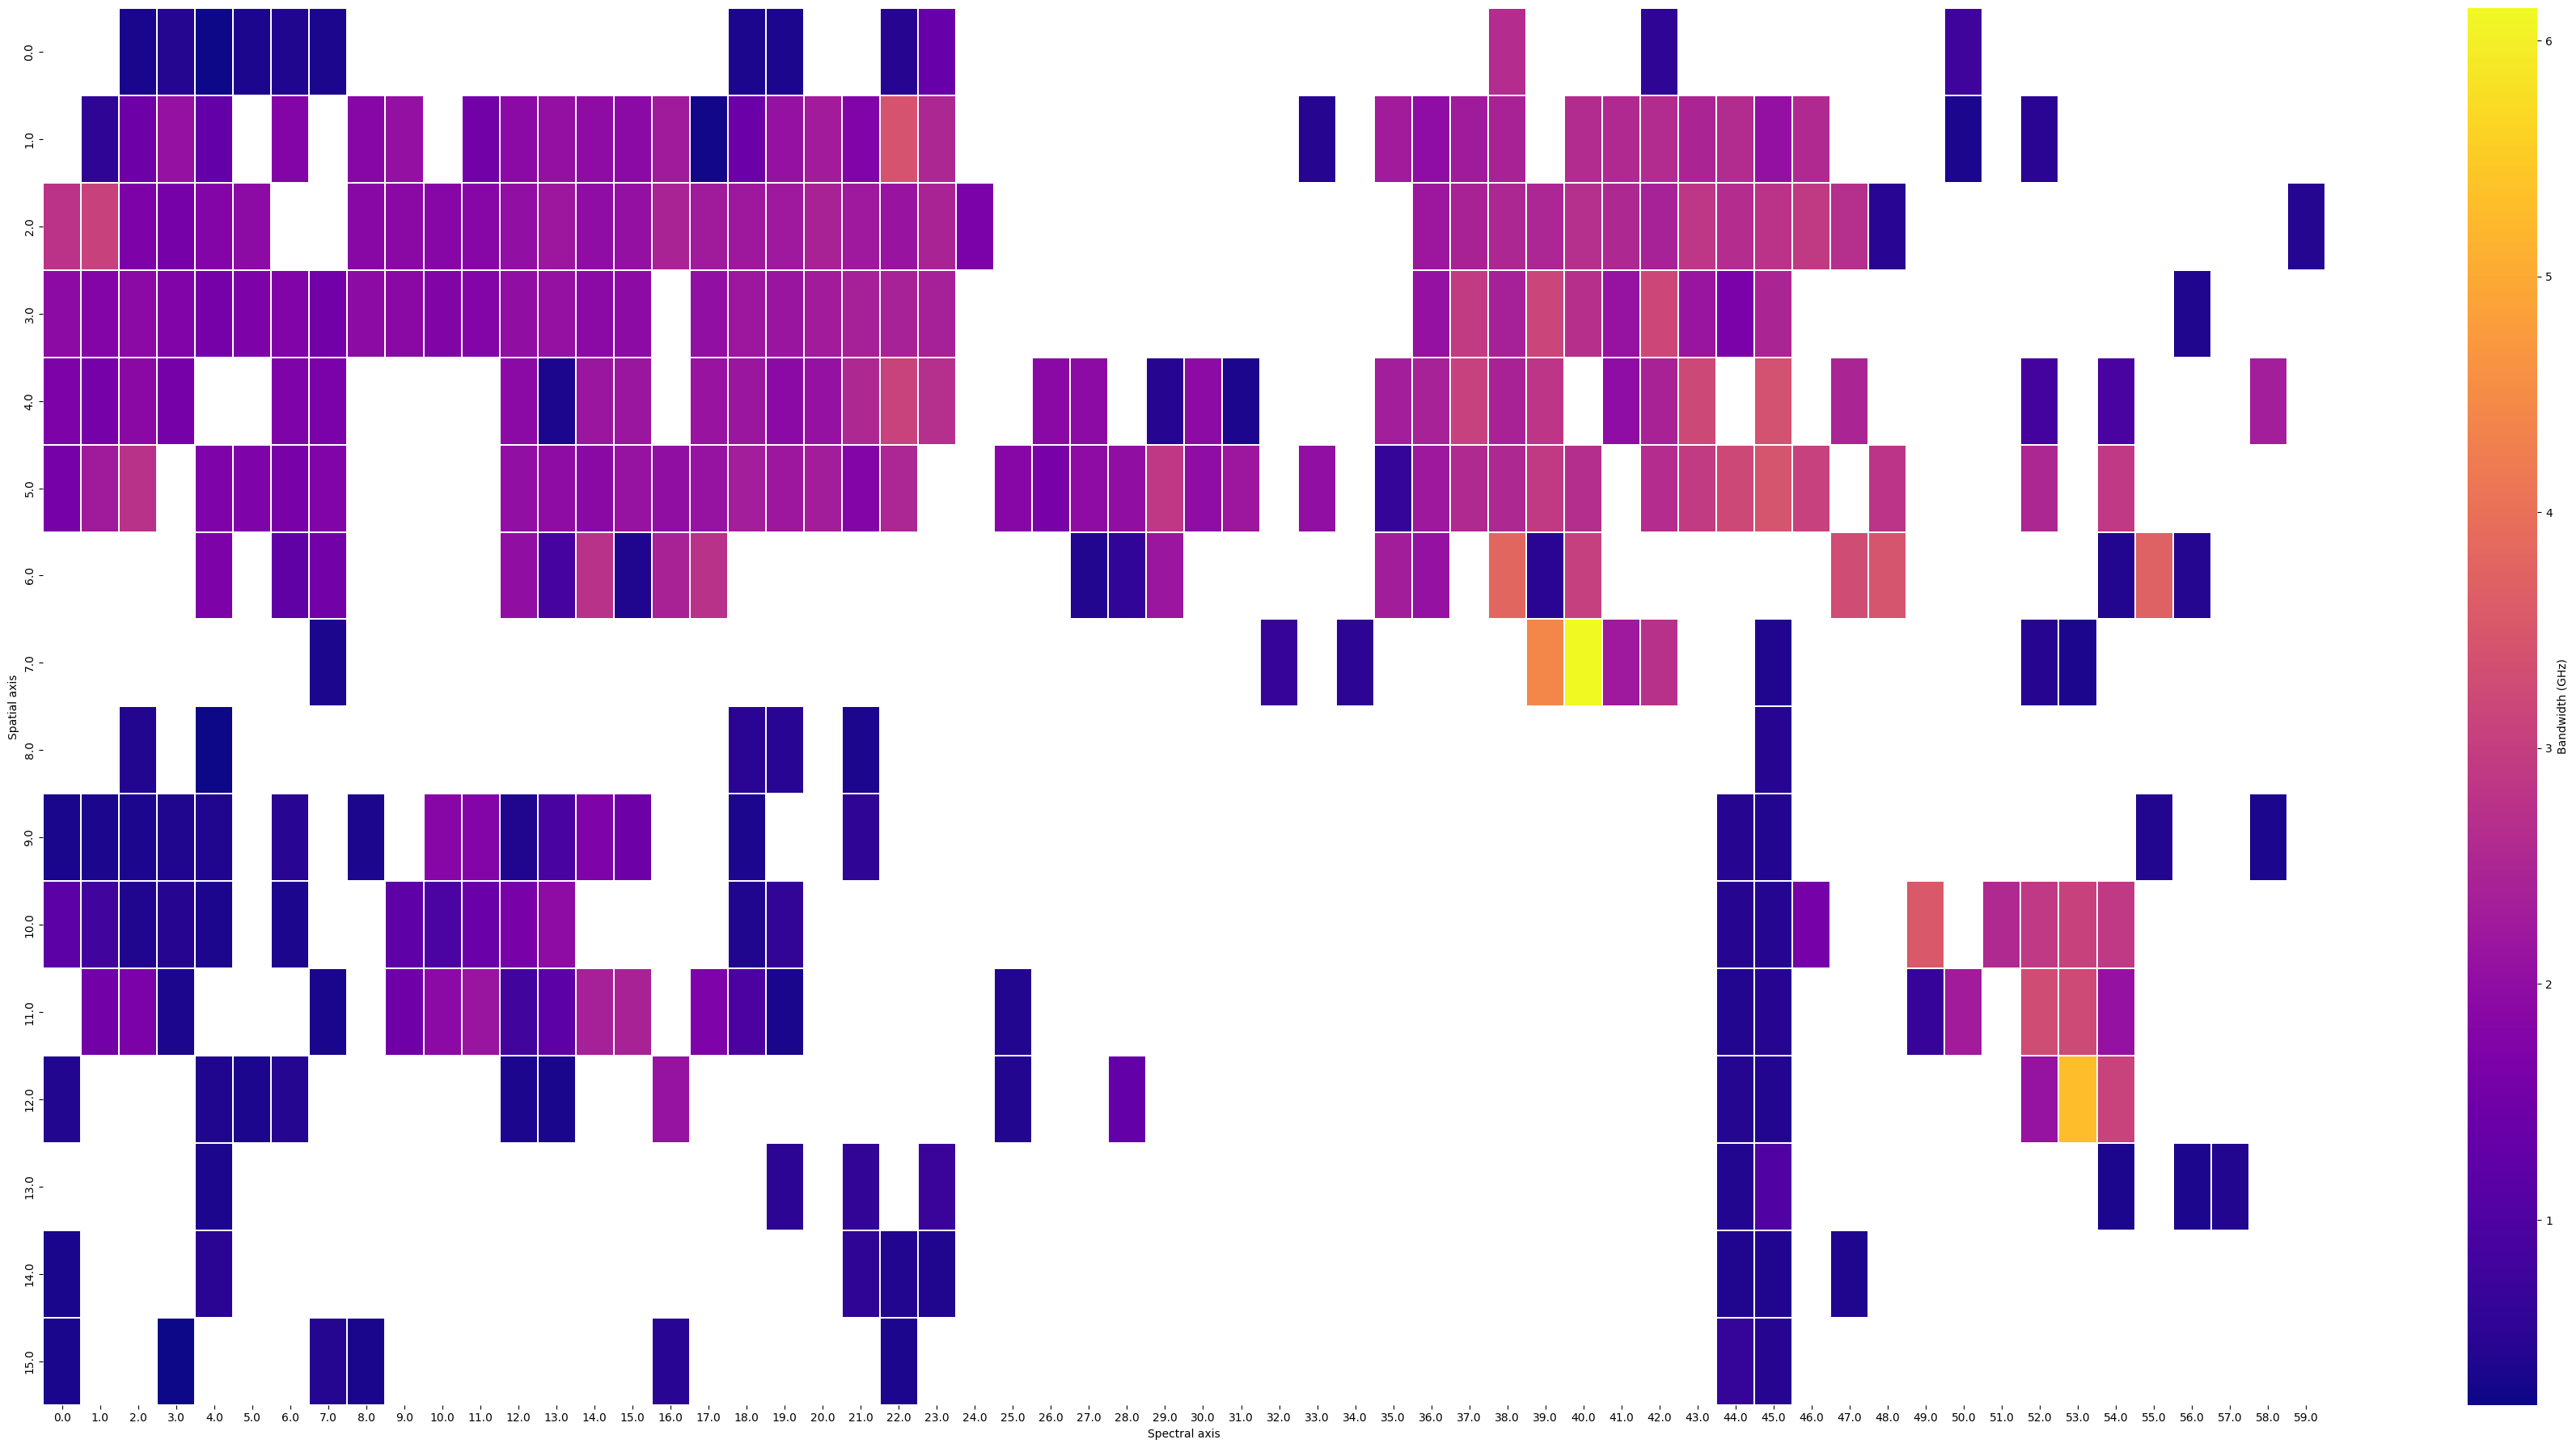

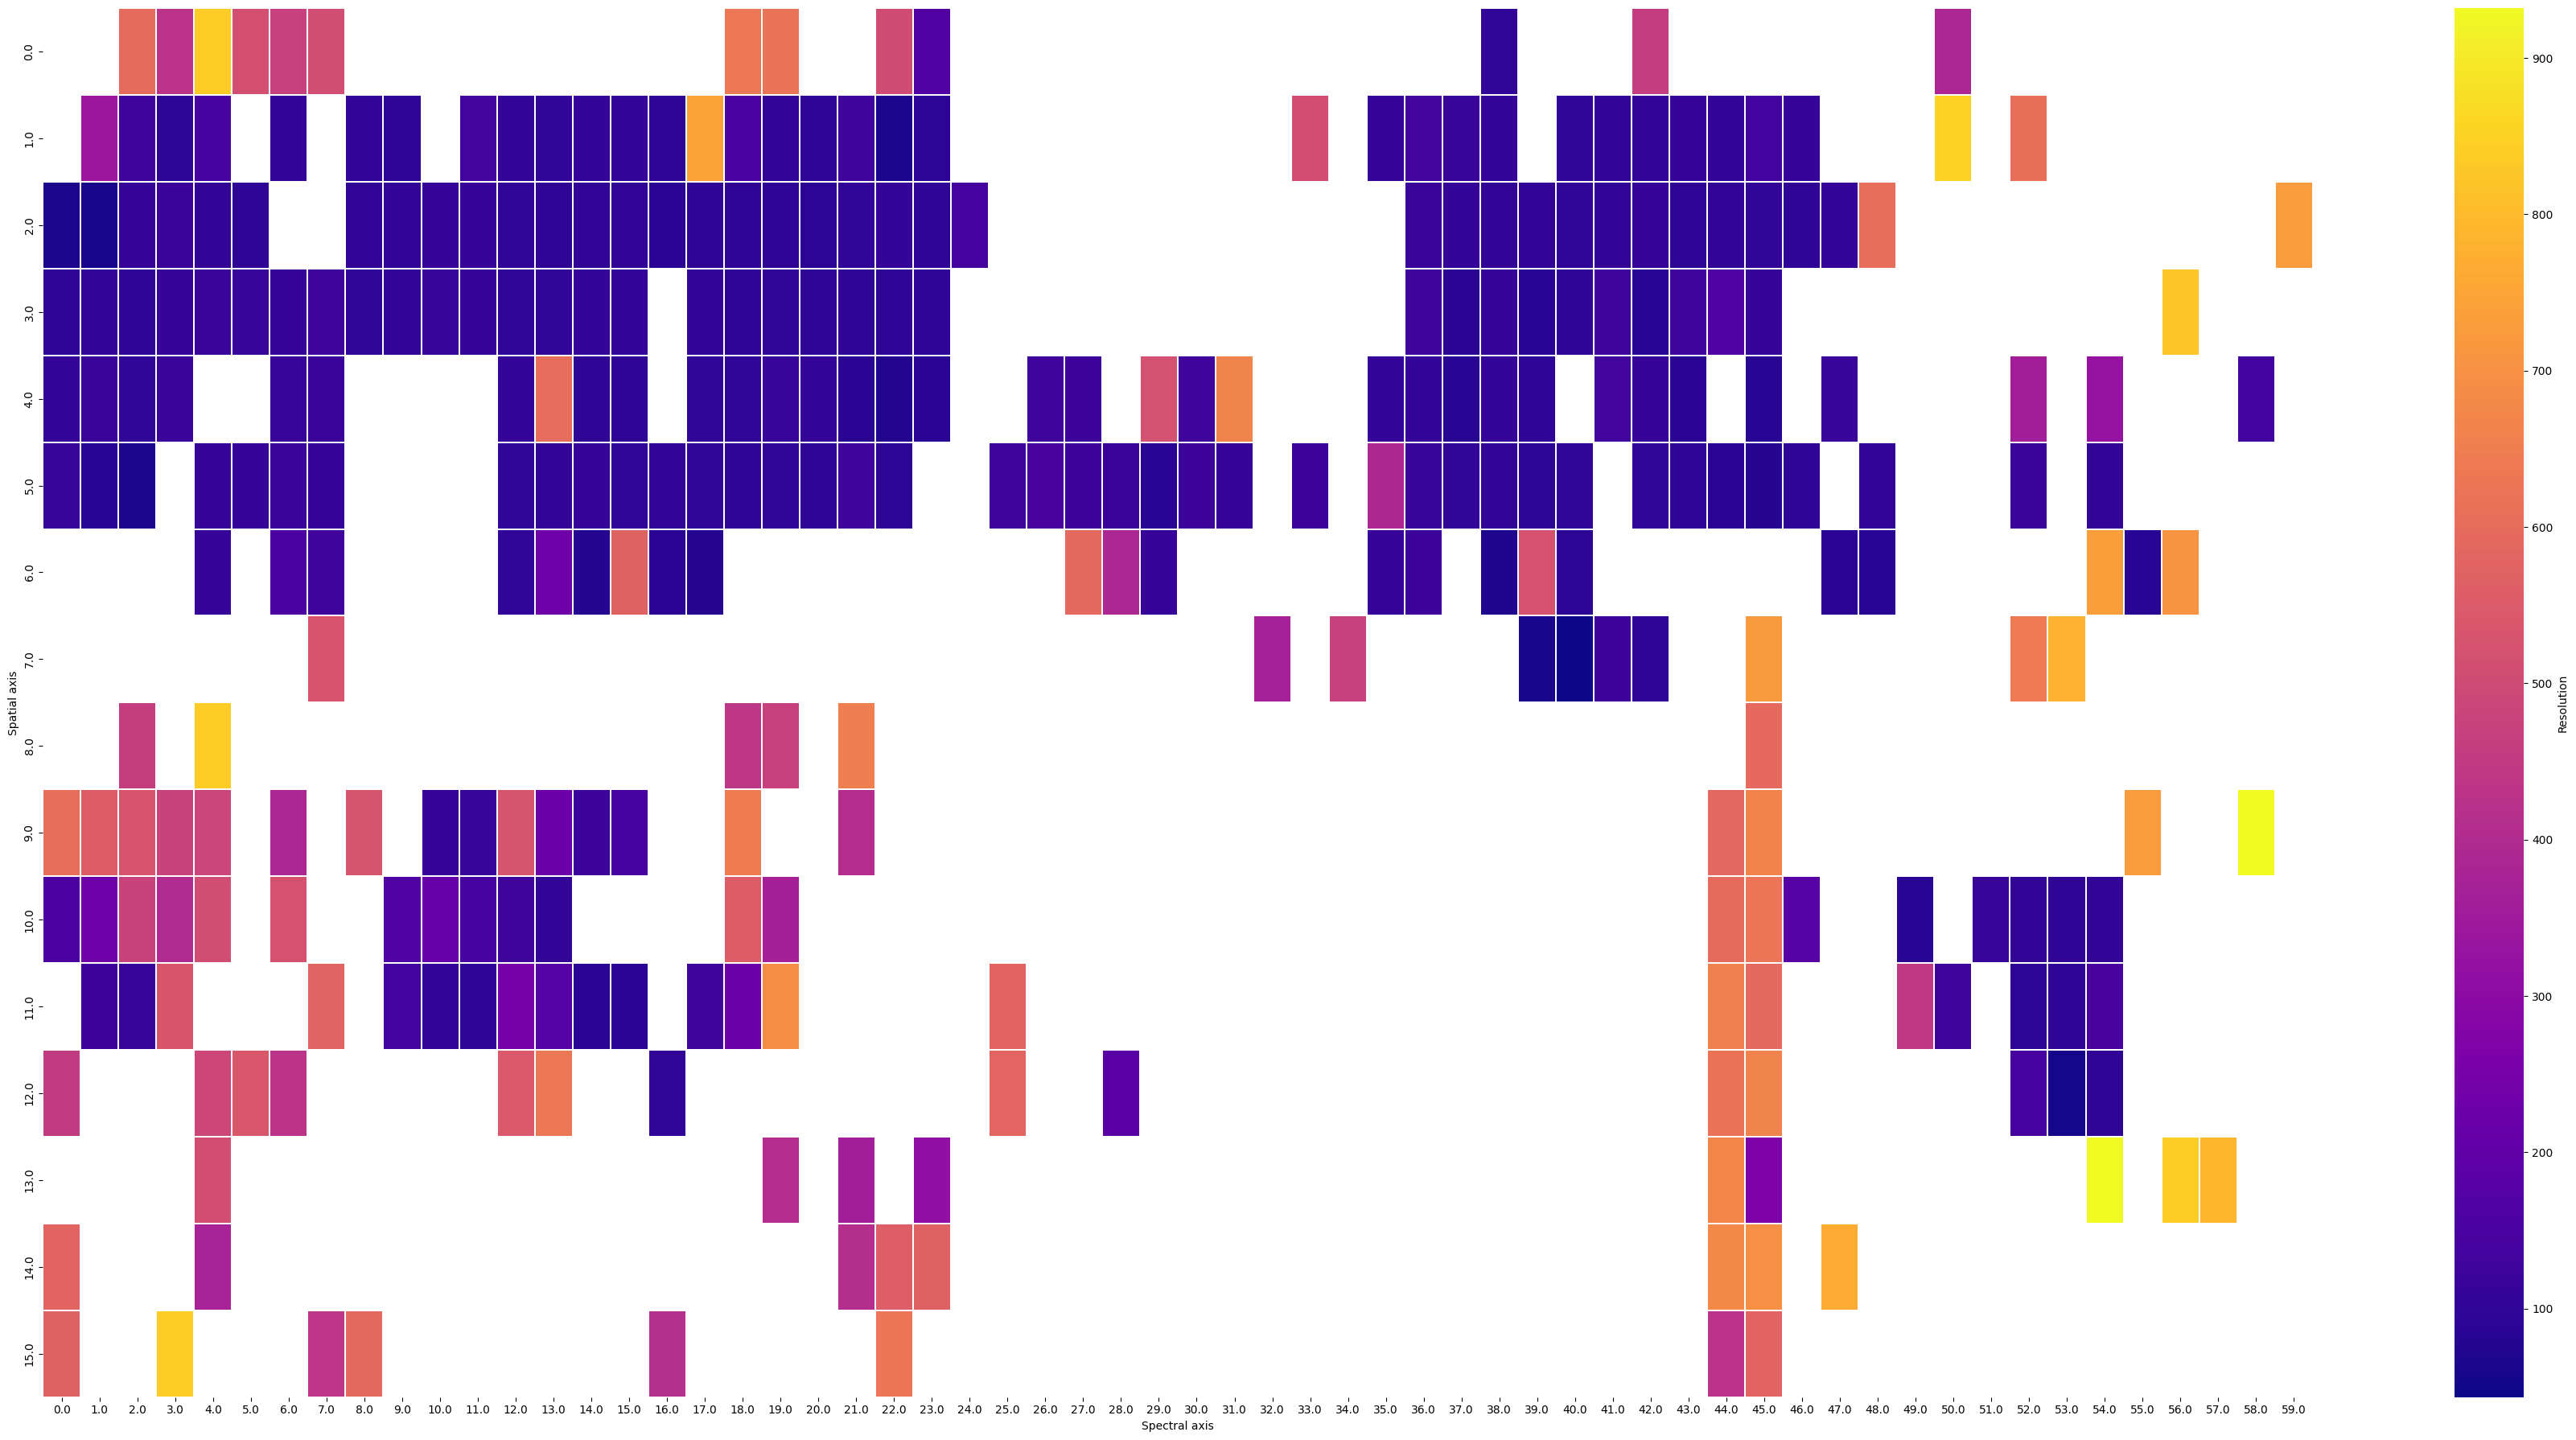

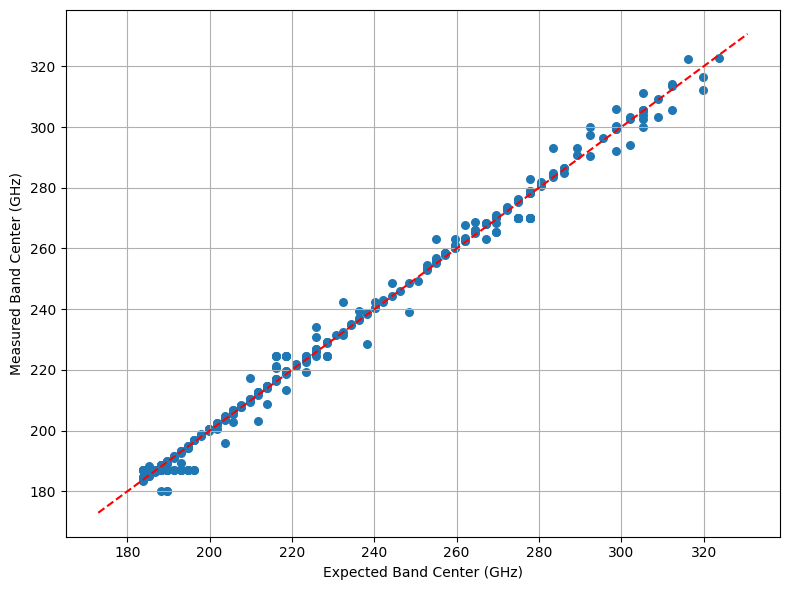

In [7]:

mce0_df['R'] = mce0_df['center'] / mce0_df['fwhm'] # R = H_0 / FWHM
pivot_fwhm = mce0_df.pivot_table(index='xf0', columns='xf1', values='fwhm', aggfunc='median')

plt.figure(figsize=(36,18))
sns.heatmap(pivot_fwhm, annot=False, fmt=".1f", cmap='plasma', cbar_kws={'label': 'Bandwidth (GHz)'}, linewidths=0.1, linecolor='white')
plt.xlabel('Spectral axis')
plt.ylabel('Spatial axis')
plt.tight_layout()
plt.show()

pivot_resolution = mce0_df.pivot_table(index='xf0', columns='xf1', values='R', aggfunc='median')

plt.figure(figsize=(36,18))
sns.heatmap(pivot_resolution, annot=False, fmt=".1f", cmap='plasma', cbar_kws={'label': 'Resolution'}, linewidths=0.1, linecolor='white',)
plt.xlabel('Spectral axis')
plt.ylabel('Spatial axis')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(mce0_df['expected_center'], mce0_df['center'], s = 30)

plt.xlabel('Expected Band Center (GHz)')
plt.ylabel('Measured Band Center (GHz)')

xlims = plt.xlim()
ylims = plt.ylim()
lims = [max(min(xlims[0], ylims[0]), 0), min(max(xlims[1], ylims[1]), 400)]
plt.plot(lims, lims, 'r--', label='y = x')

plt.grid(True)
plt.tight_layout()
plt.show()

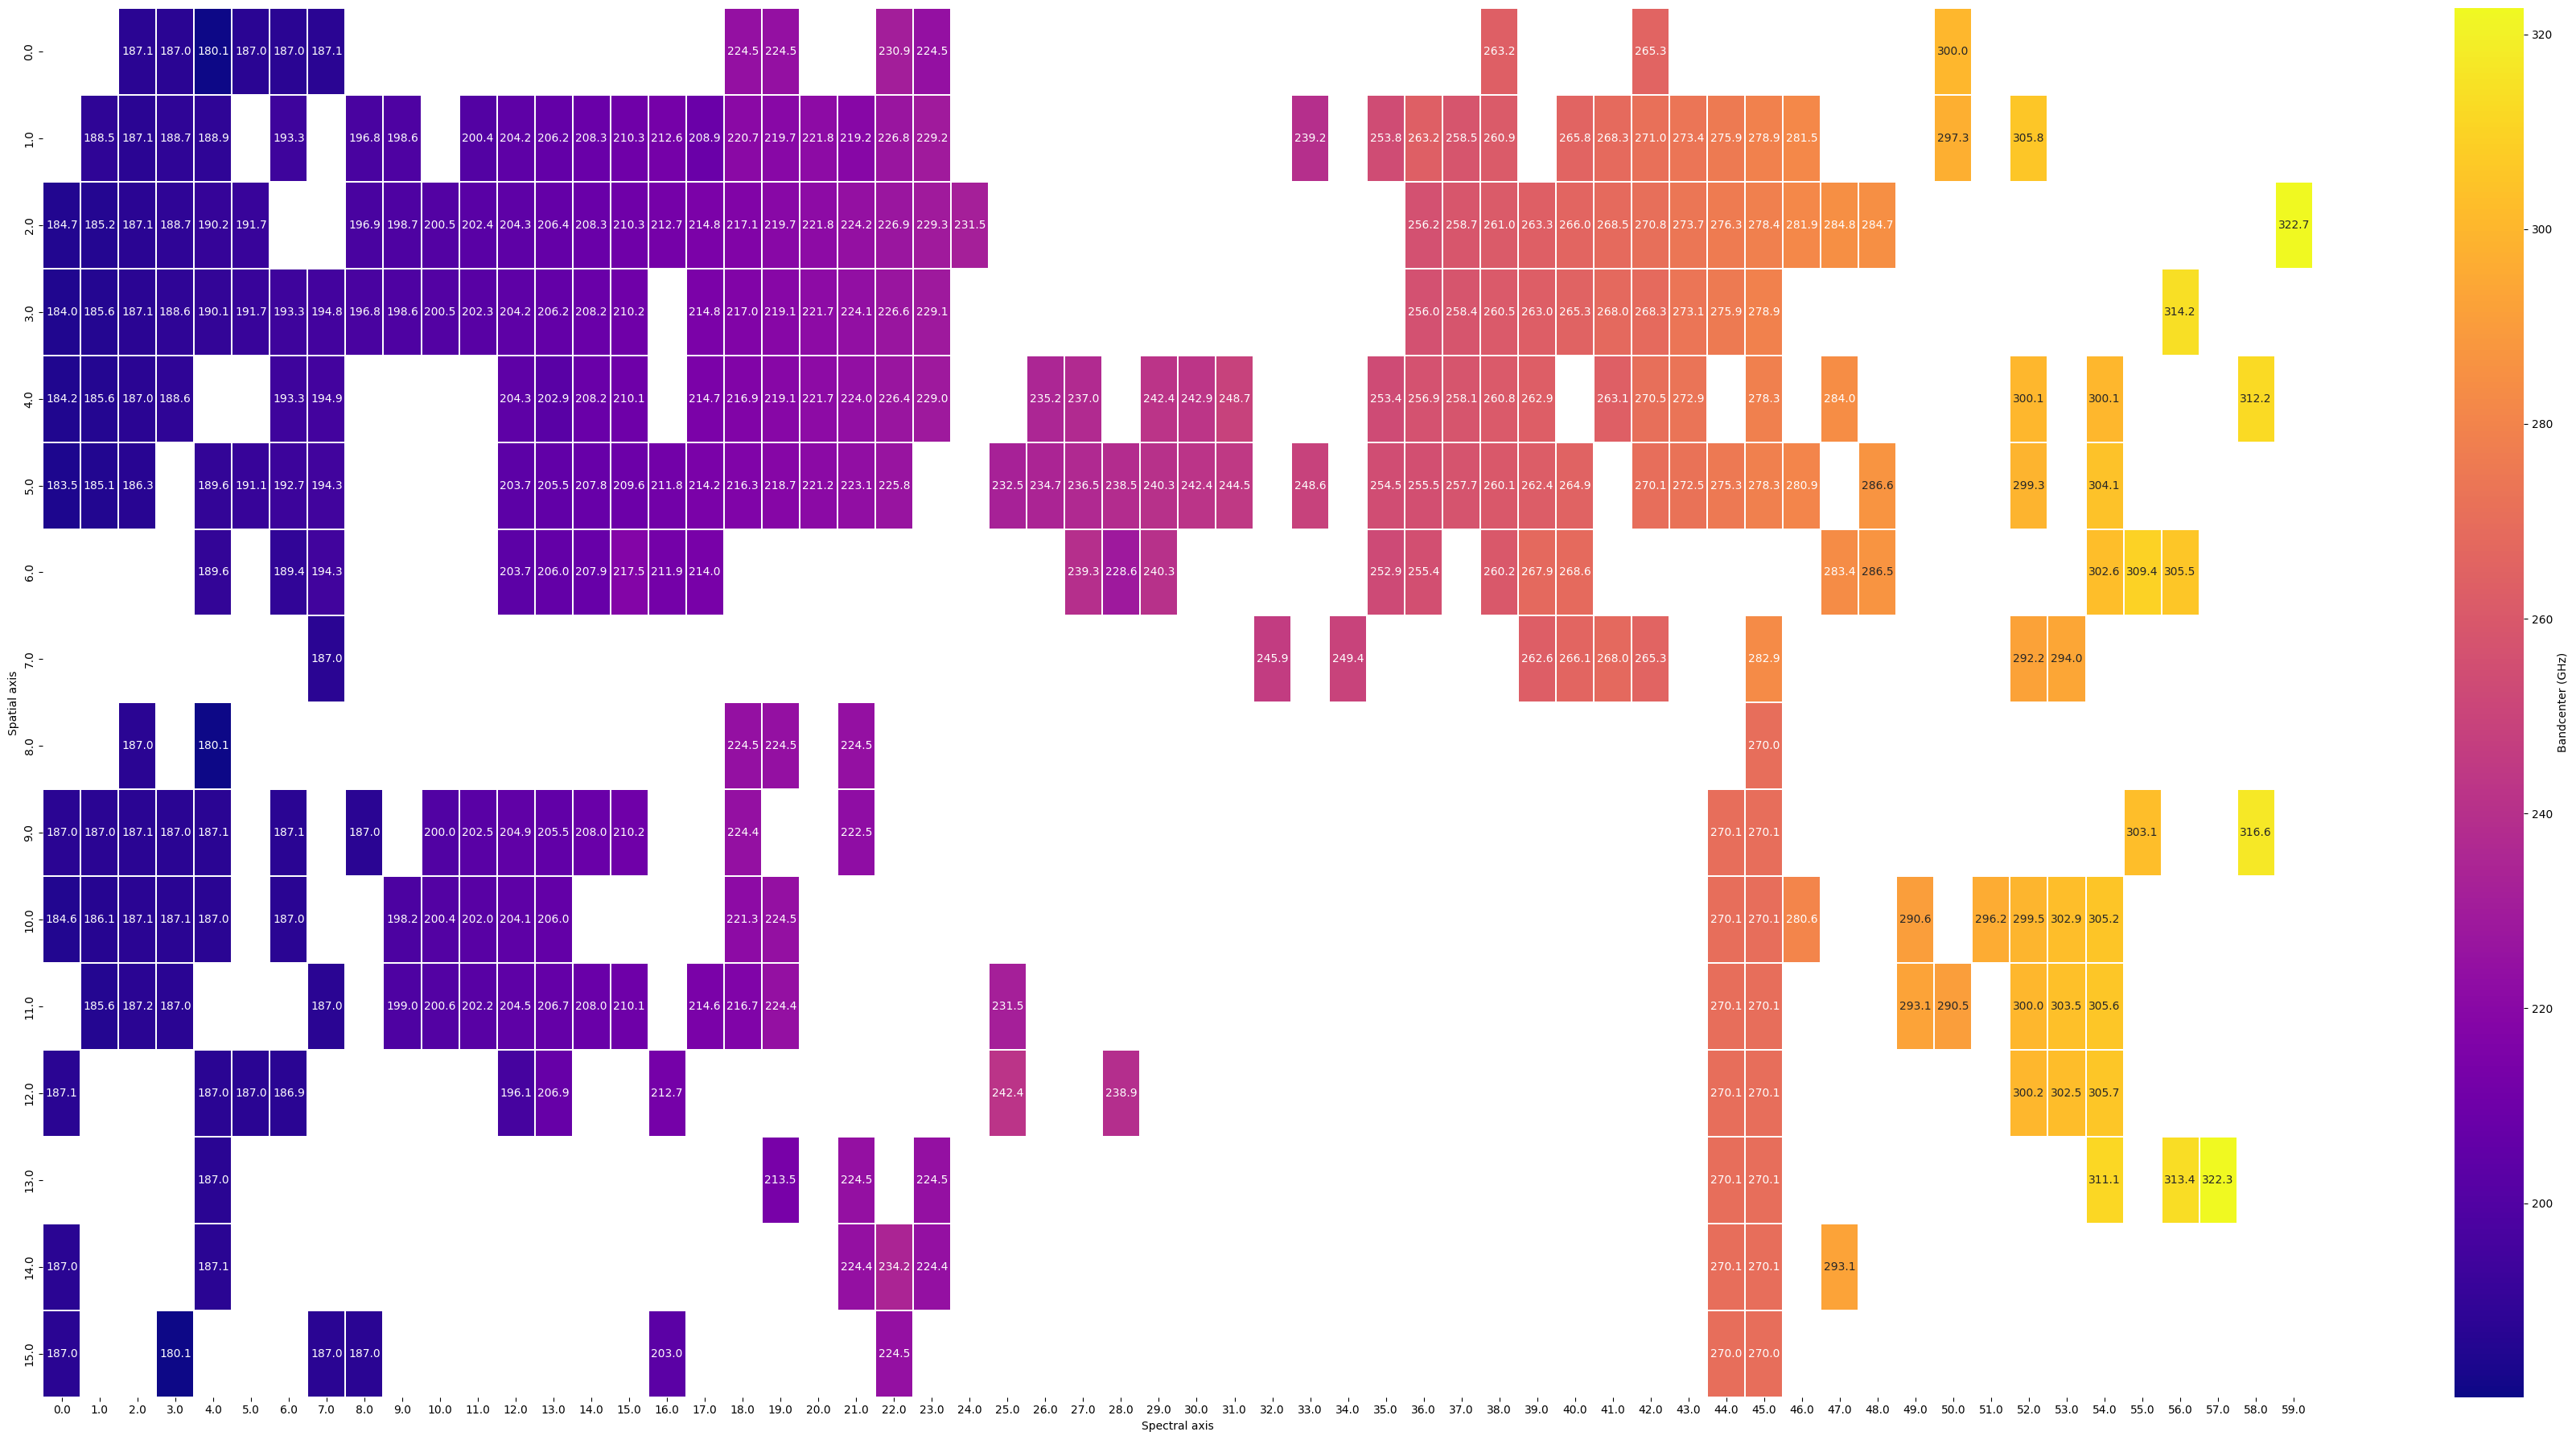

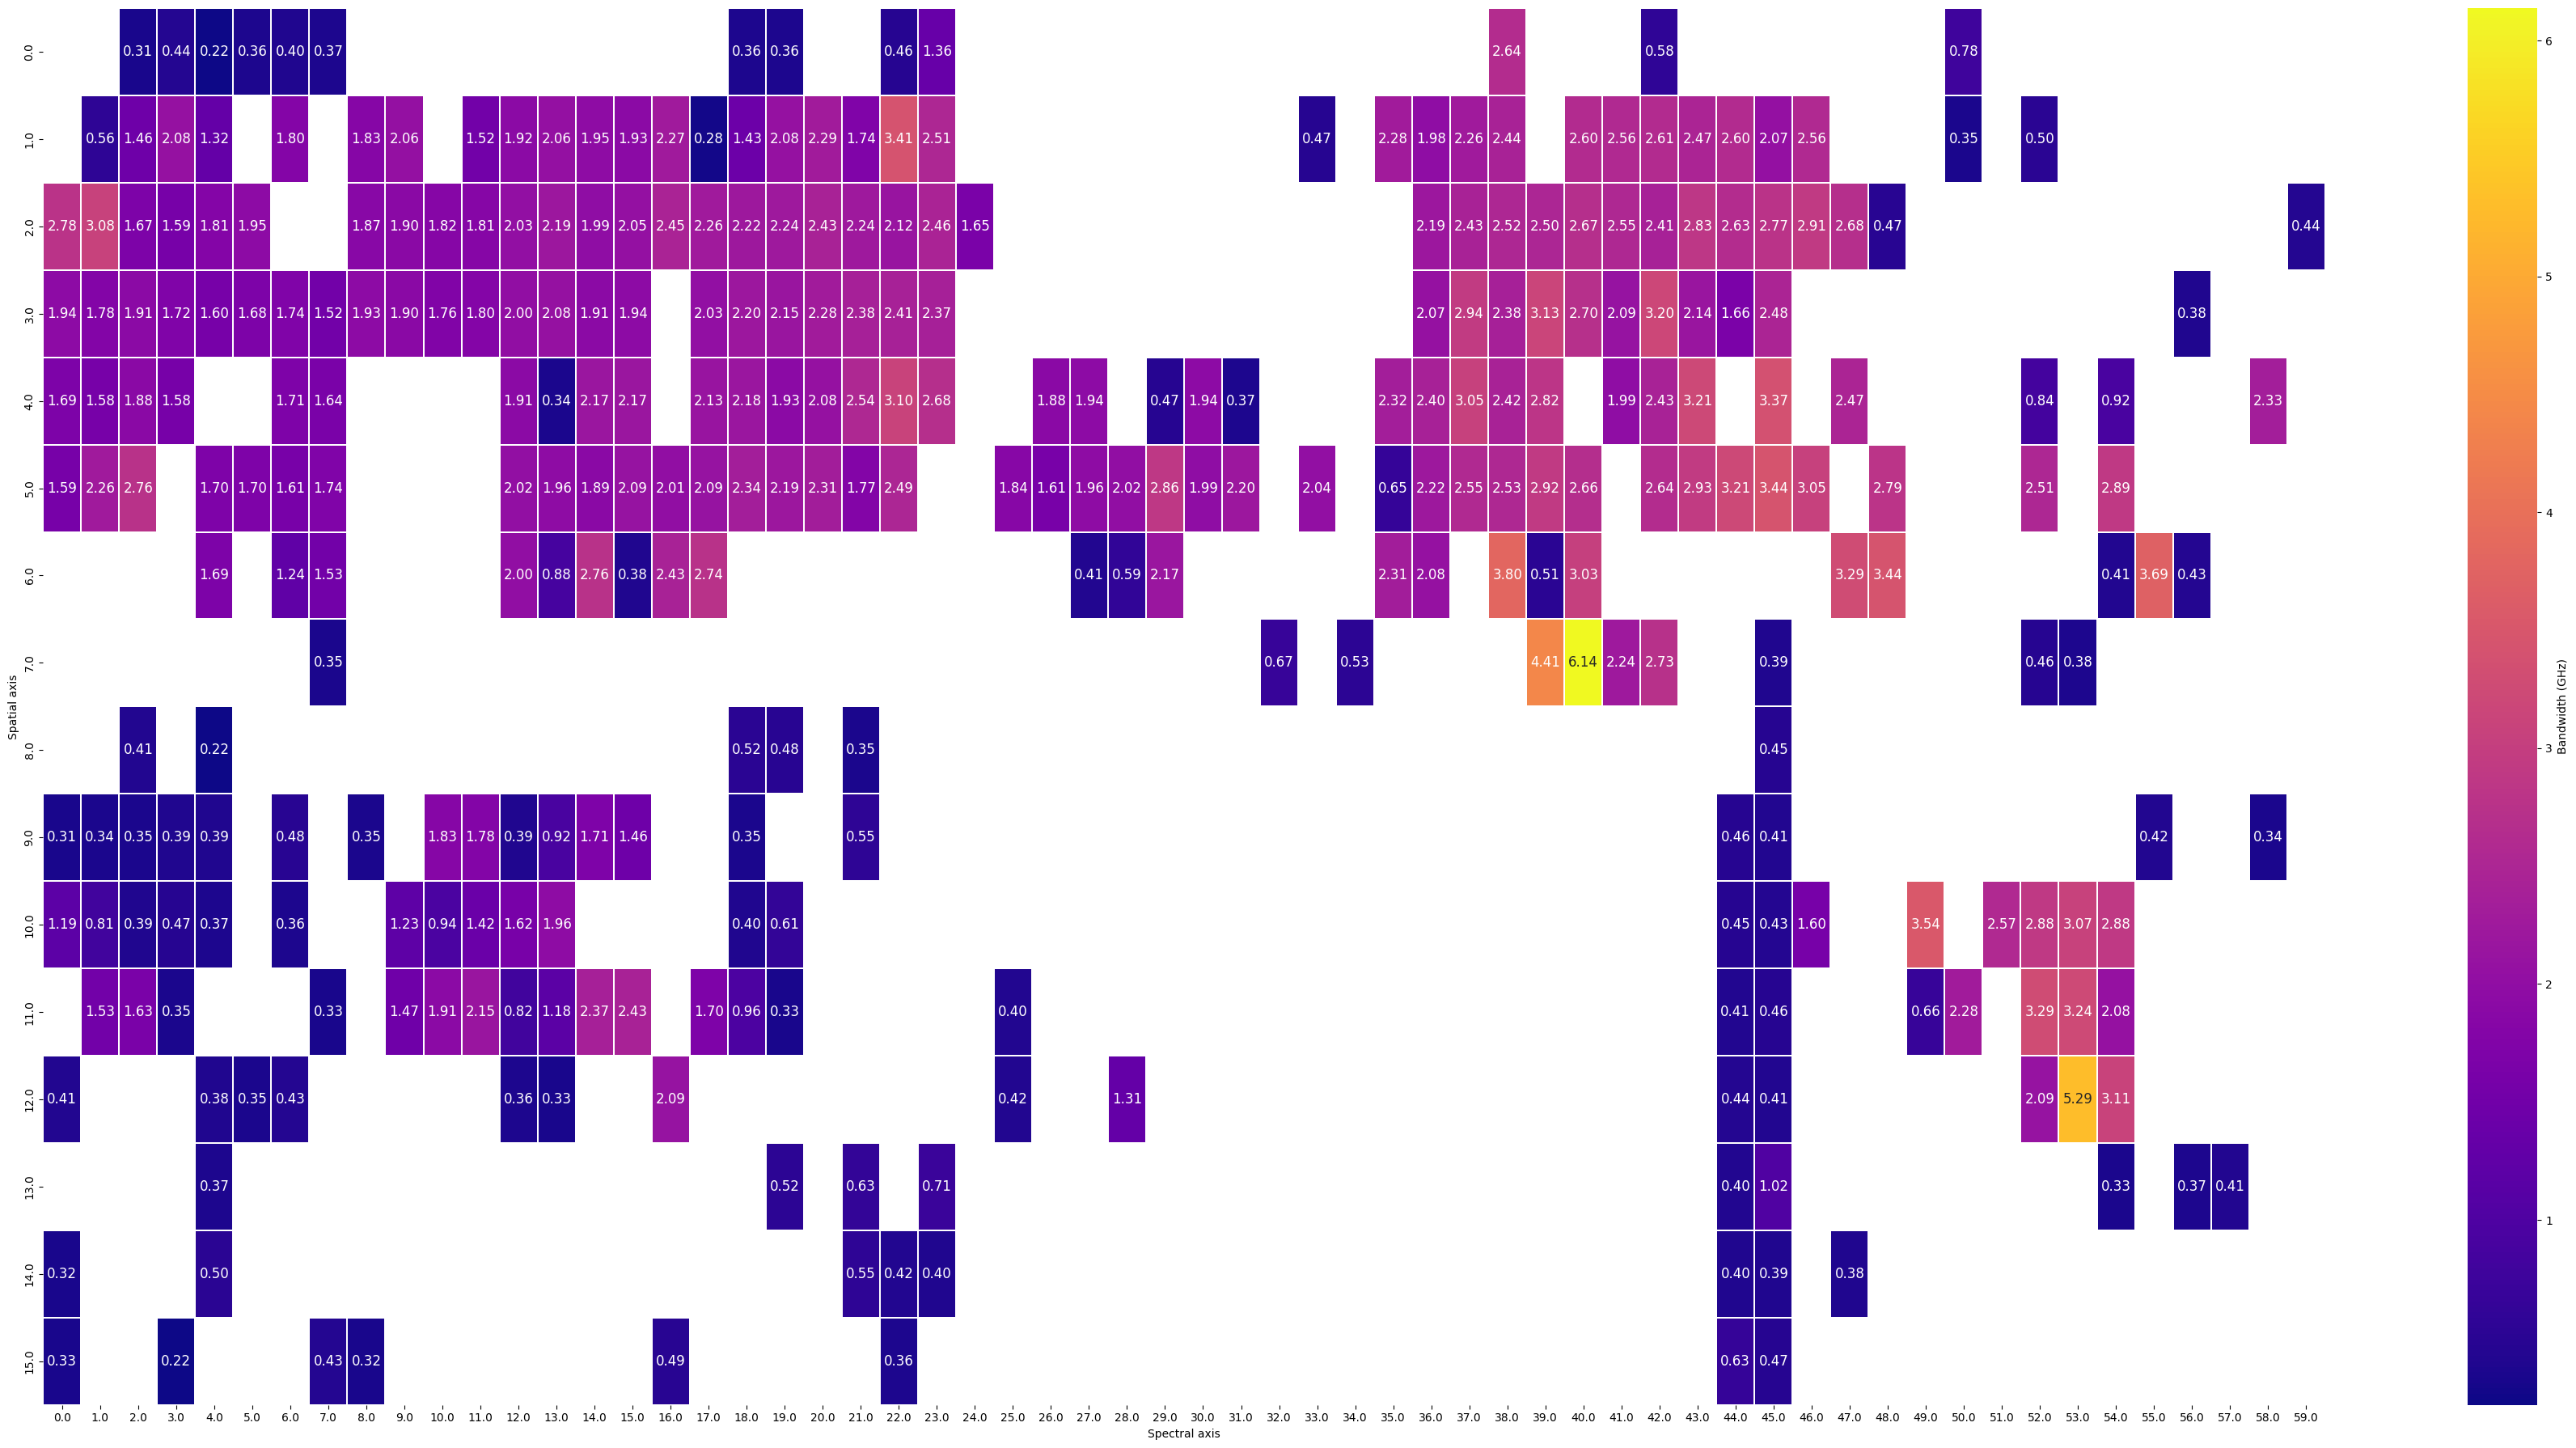

In [8]:

pivot_center = mce0_df.pivot_table(index='xf0', columns='xf1', values='center', aggfunc='median')

plt.figure(figsize=(36,18))
sns.heatmap(pivot_center, annot=True, fmt=".1f", cmap='plasma', cbar_kws={'label': 'Bandcenter (GHz)'}, linewidths=0.1, linecolor='white', annot_kws={"size": 10})
plt.xlabel('Spectral axis')
plt.ylabel('Spatial axis')
plt.tight_layout()
plt.show()

pivot_fwhm = mce0_df.pivot_table(index='xf0', columns='xf1', values='fwhm', aggfunc='median')

plt.figure(figsize=(36,18))
sns.heatmap(pivot_fwhm, annot=True, fmt=".2f", cmap='plasma', cbar_kws={'label': 'Bandwidth (GHz)'}, linewidths=0.1, linecolor='white' , annot_kws={"size": 12},)
plt.xlabel('Spectral axis')
plt.ylabel('Spatial axis')
plt.tight_layout()
plt.show()

In [9]:
data_paths_1 = ["bandwidth.csv filepaths here.."]

In [10]:
mce1_df = df_mapping(data_paths_1, CENTER_TOL, FWHM_TOL)
print(len(mce1_df))

135


In [11]:
print(r2_score_identity(mce1_df['expected_center'], mce1_df['center']))

0.9773826121749533


135


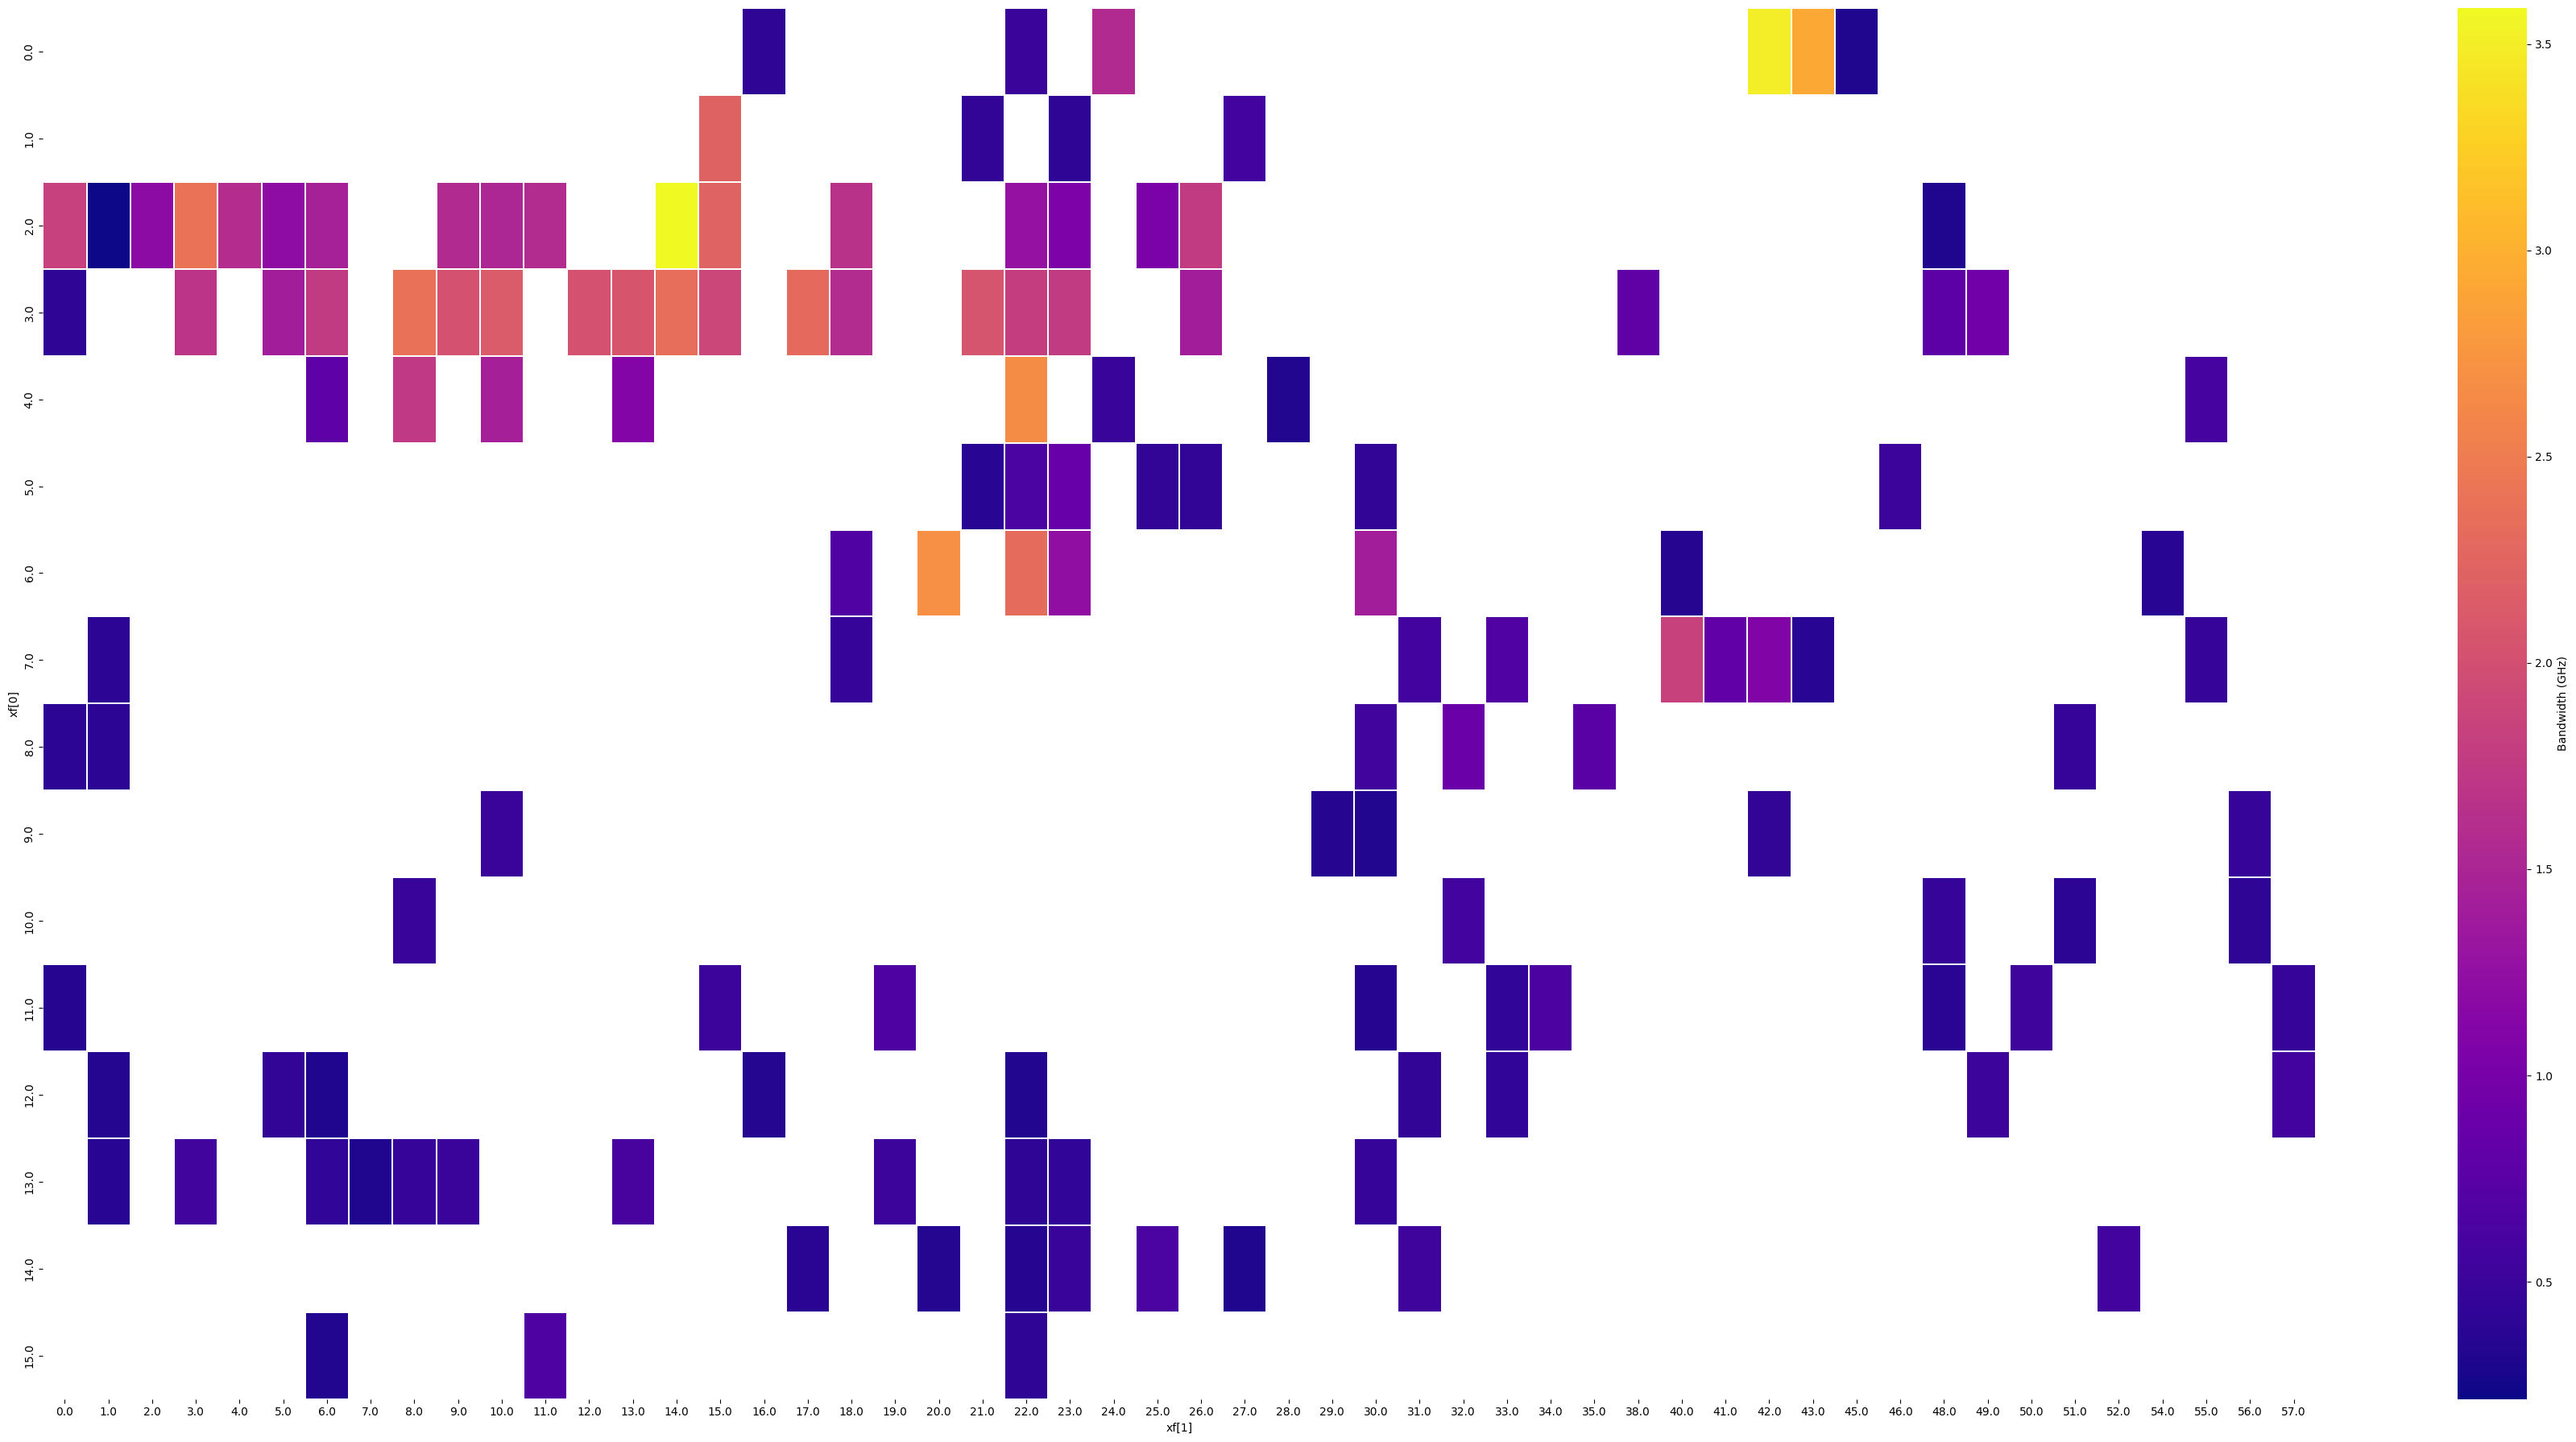

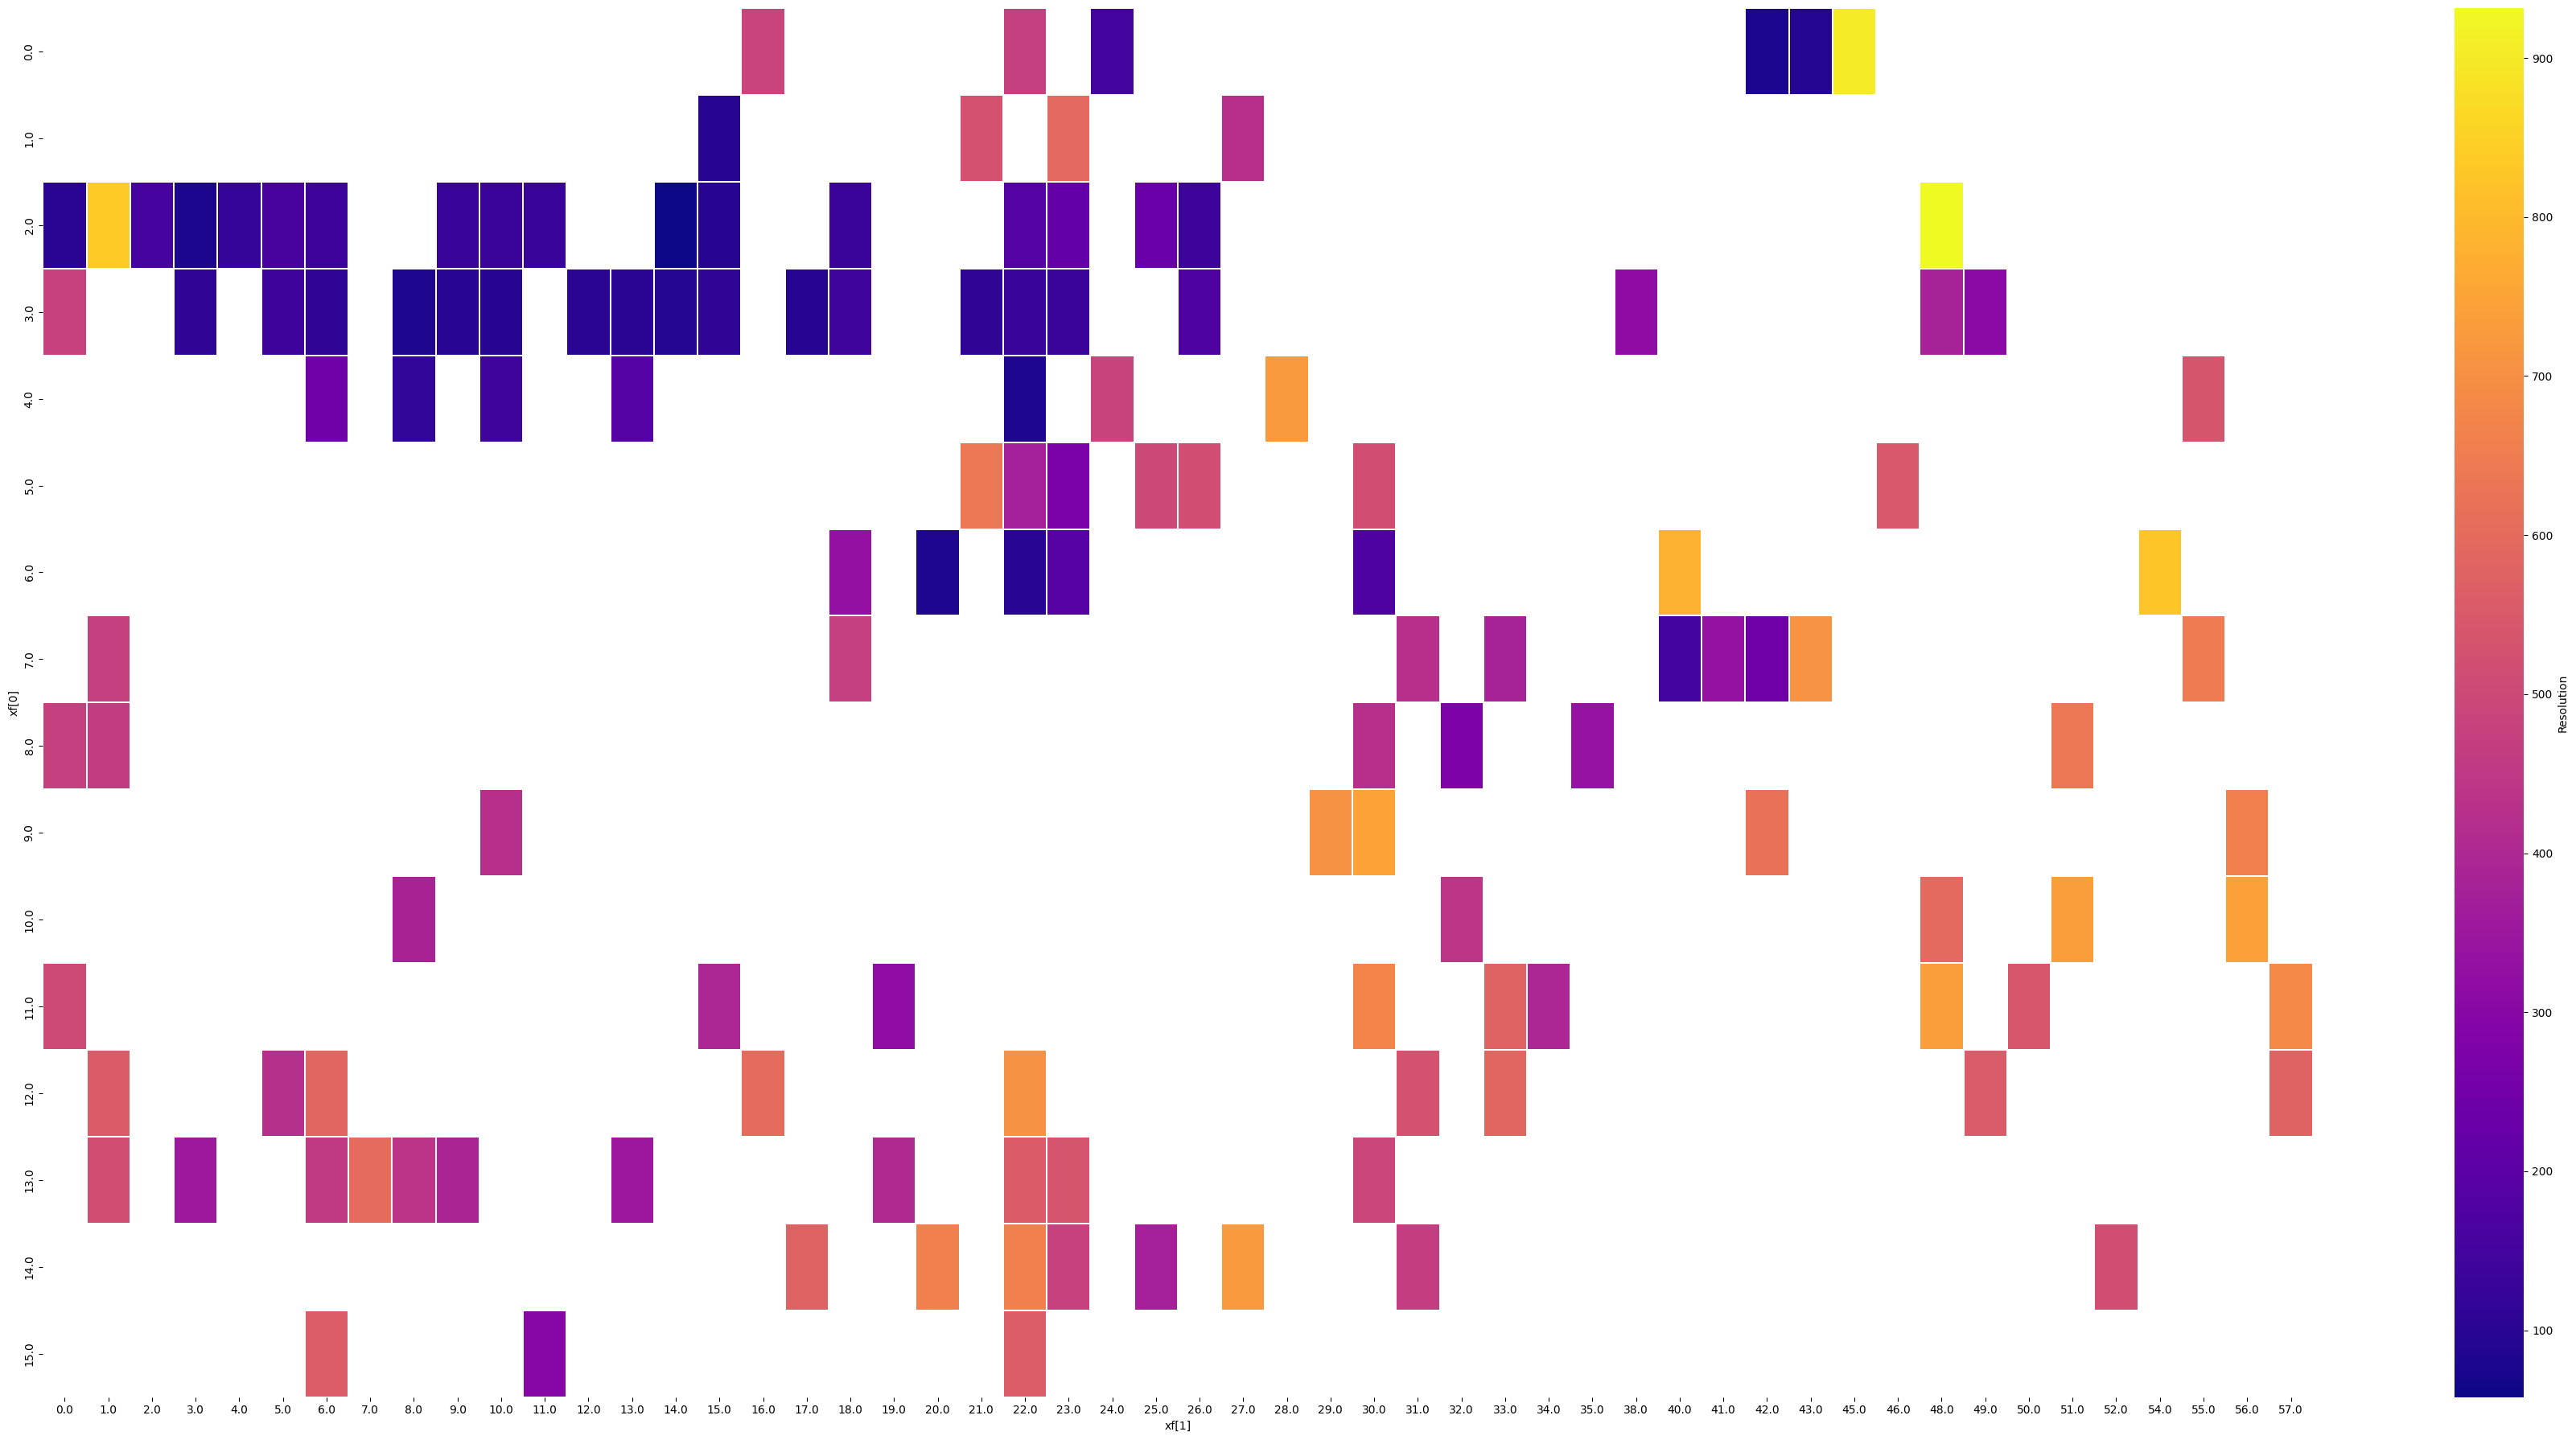

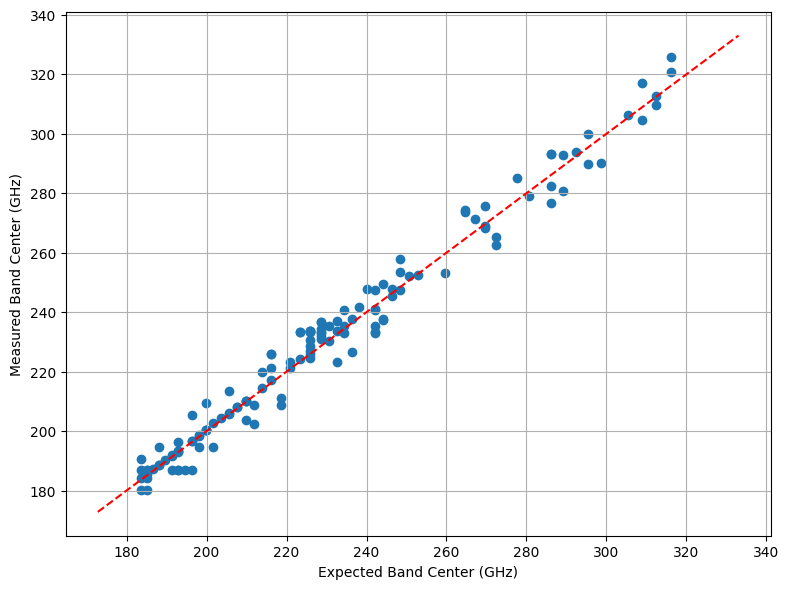

In [12]:
mce1_df['R'] = mce1_df['center'] / mce1_df['fwhm'] # R = H_0 / FWHM
print(len(mce1_df))
pivot_fwhm = mce1_df.pivot_table(index='xf0', columns='xf1', values='fwhm', aggfunc='median')

plt.figure(figsize=(36,18))
sns.heatmap(pivot_fwhm, annot=False, fmt=".1f", cmap='plasma', cbar_kws={'label': 'Bandwidth (GHz)'}, linewidths=0.1, linecolor='white',)
plt.xlabel('xf[1]')
plt.ylabel('xf[0]')
plt.tight_layout()
plt.show()

pivot_resolution = mce1_df.pivot_table(index='xf0', columns='xf1', values='R', aggfunc='median')
plt.figure(figsize=(36,18))
sns.heatmap(pivot_resolution, annot=False, fmt=".1f", cmap='plasma', cbar_kws={'label': 'Resolution'}, linewidths=0.1, linecolor='white',)
plt.xlabel('xf[1]')
plt.ylabel('xf[0]')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(mce1_df['expected_center'], mce1_df['center'])

plt.xlabel('Expected Band Center (GHz)')
plt.ylabel('Measured Band Center (GHz)')

xlims = plt.xlim()
ylims = plt.ylim()
lims = [max(min(xlims[0], ylims[0]), 0), min(max(xlims[1], ylims[1]), 400)]
plt.plot(lims, lims, 'r--', label='y = x')

plt.grid(True)
plt.tight_layout()
plt.show()

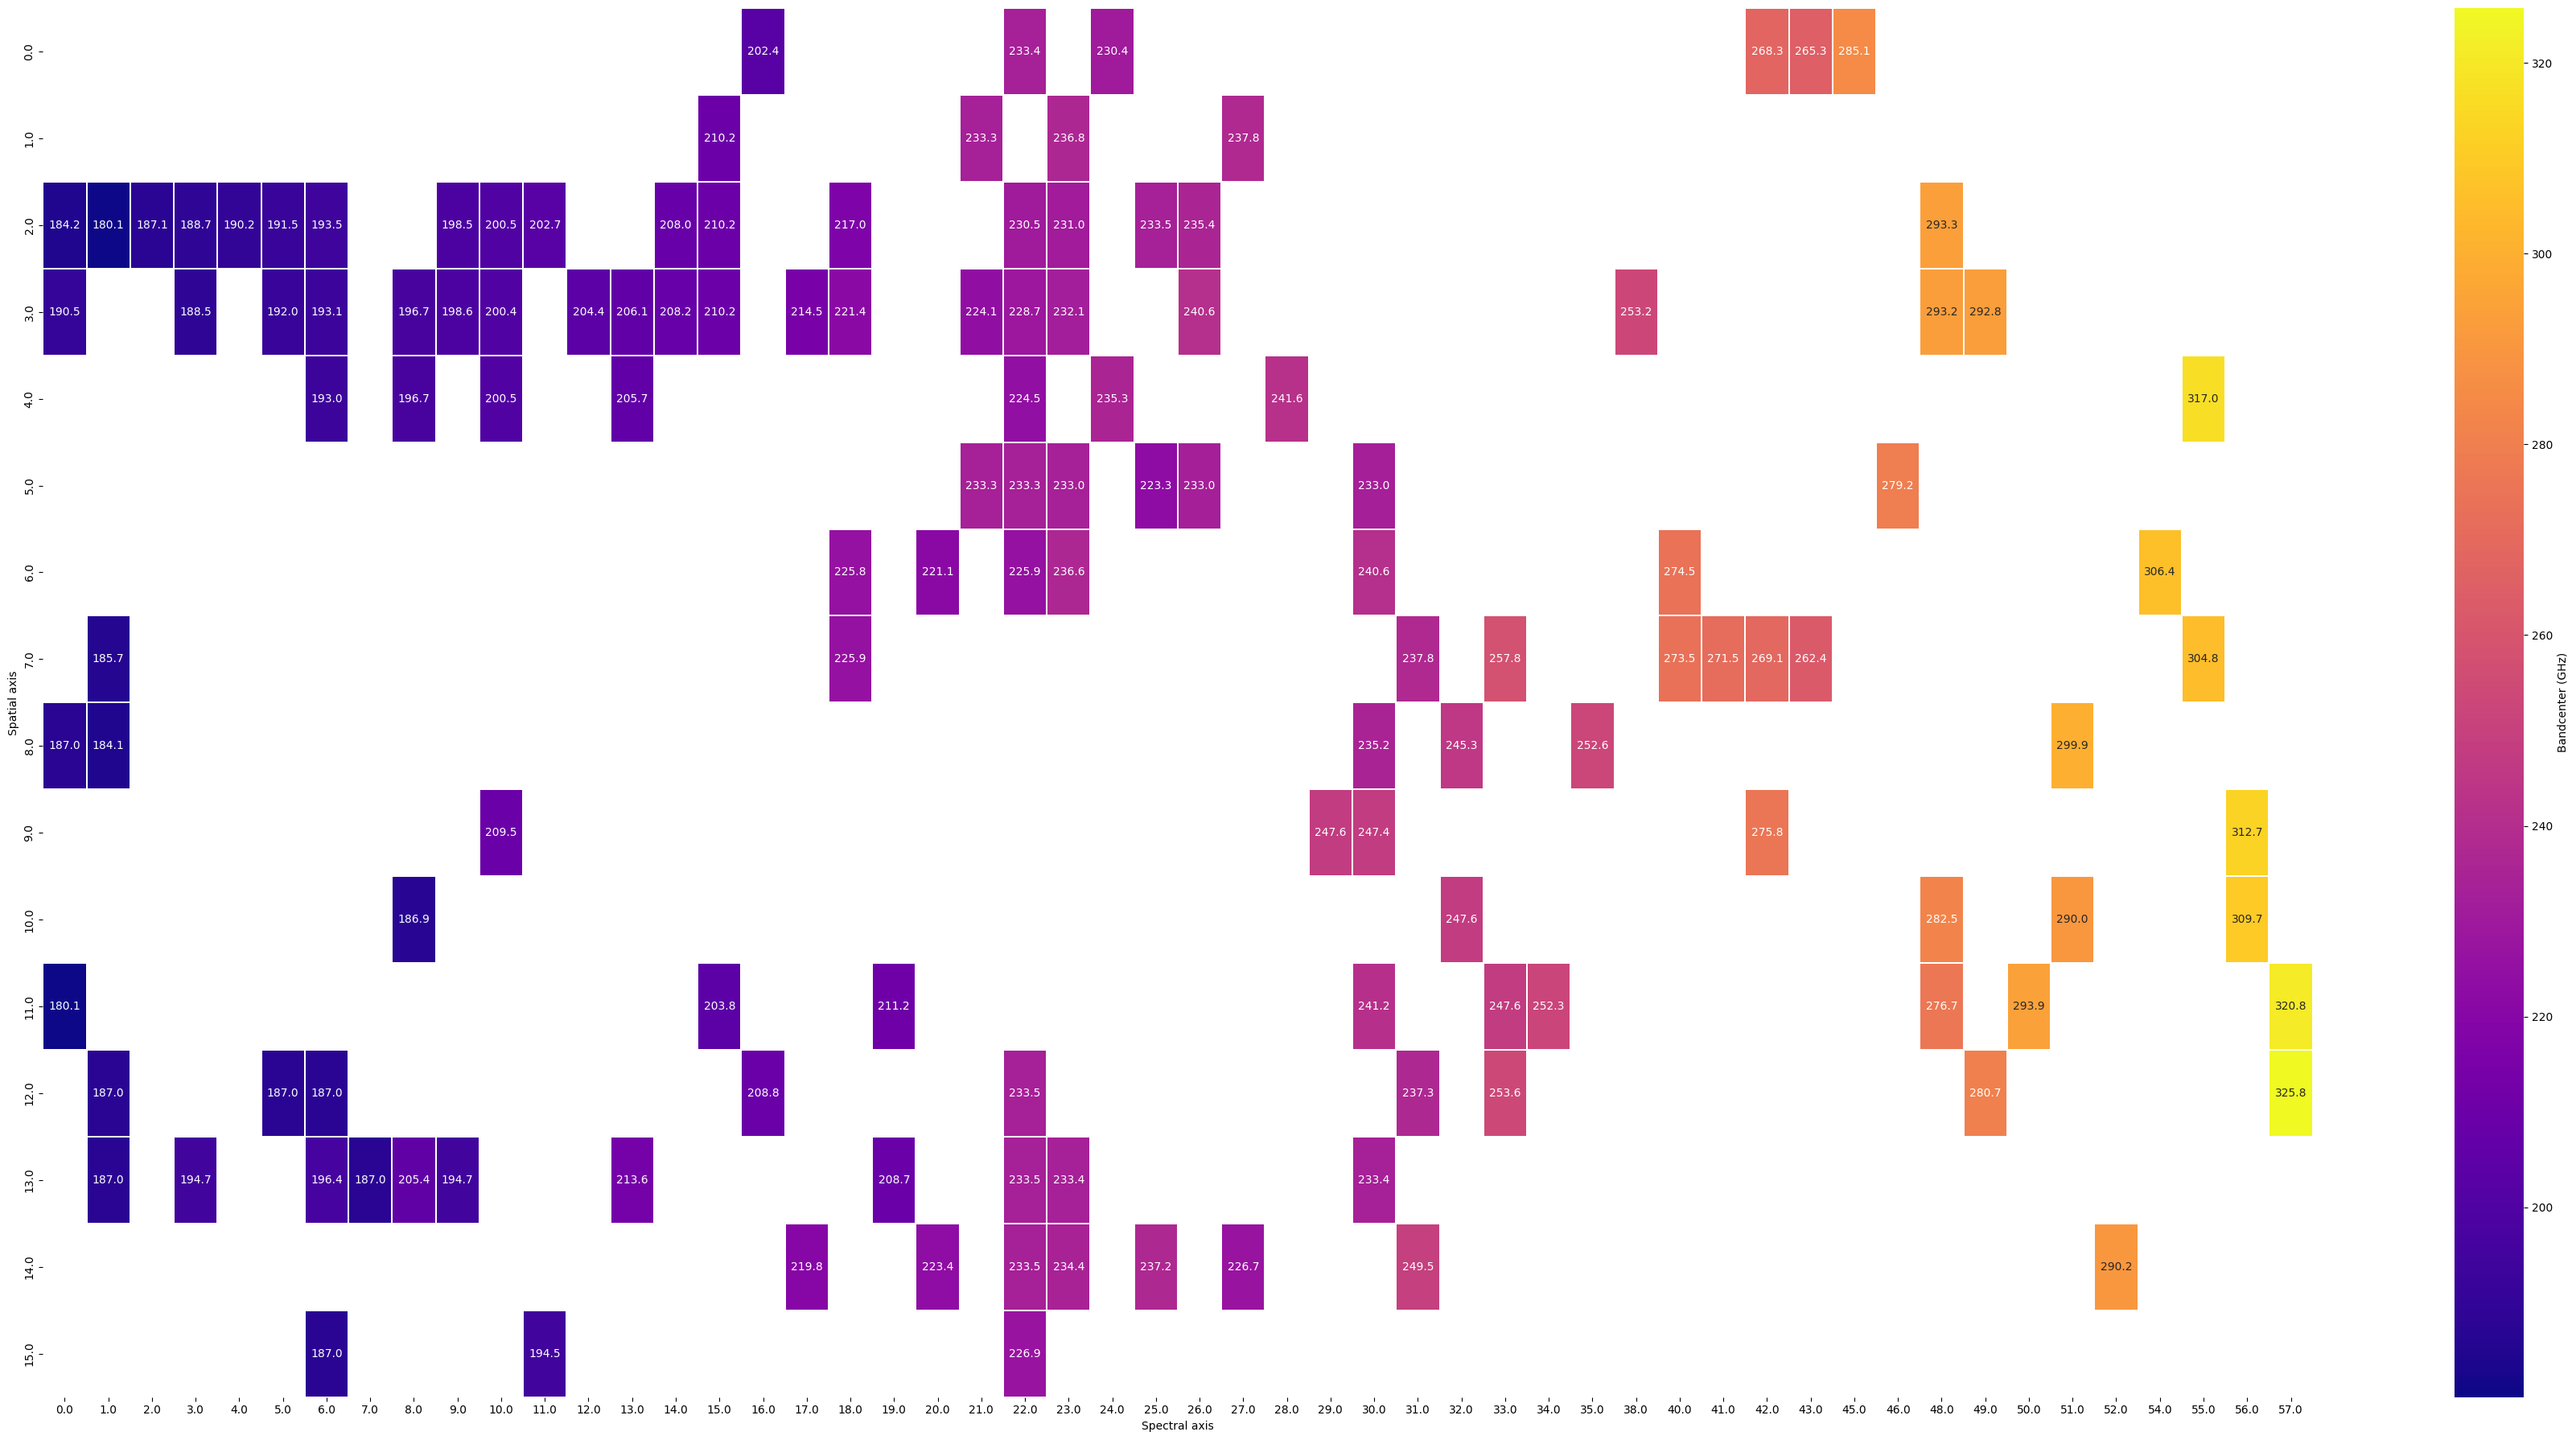

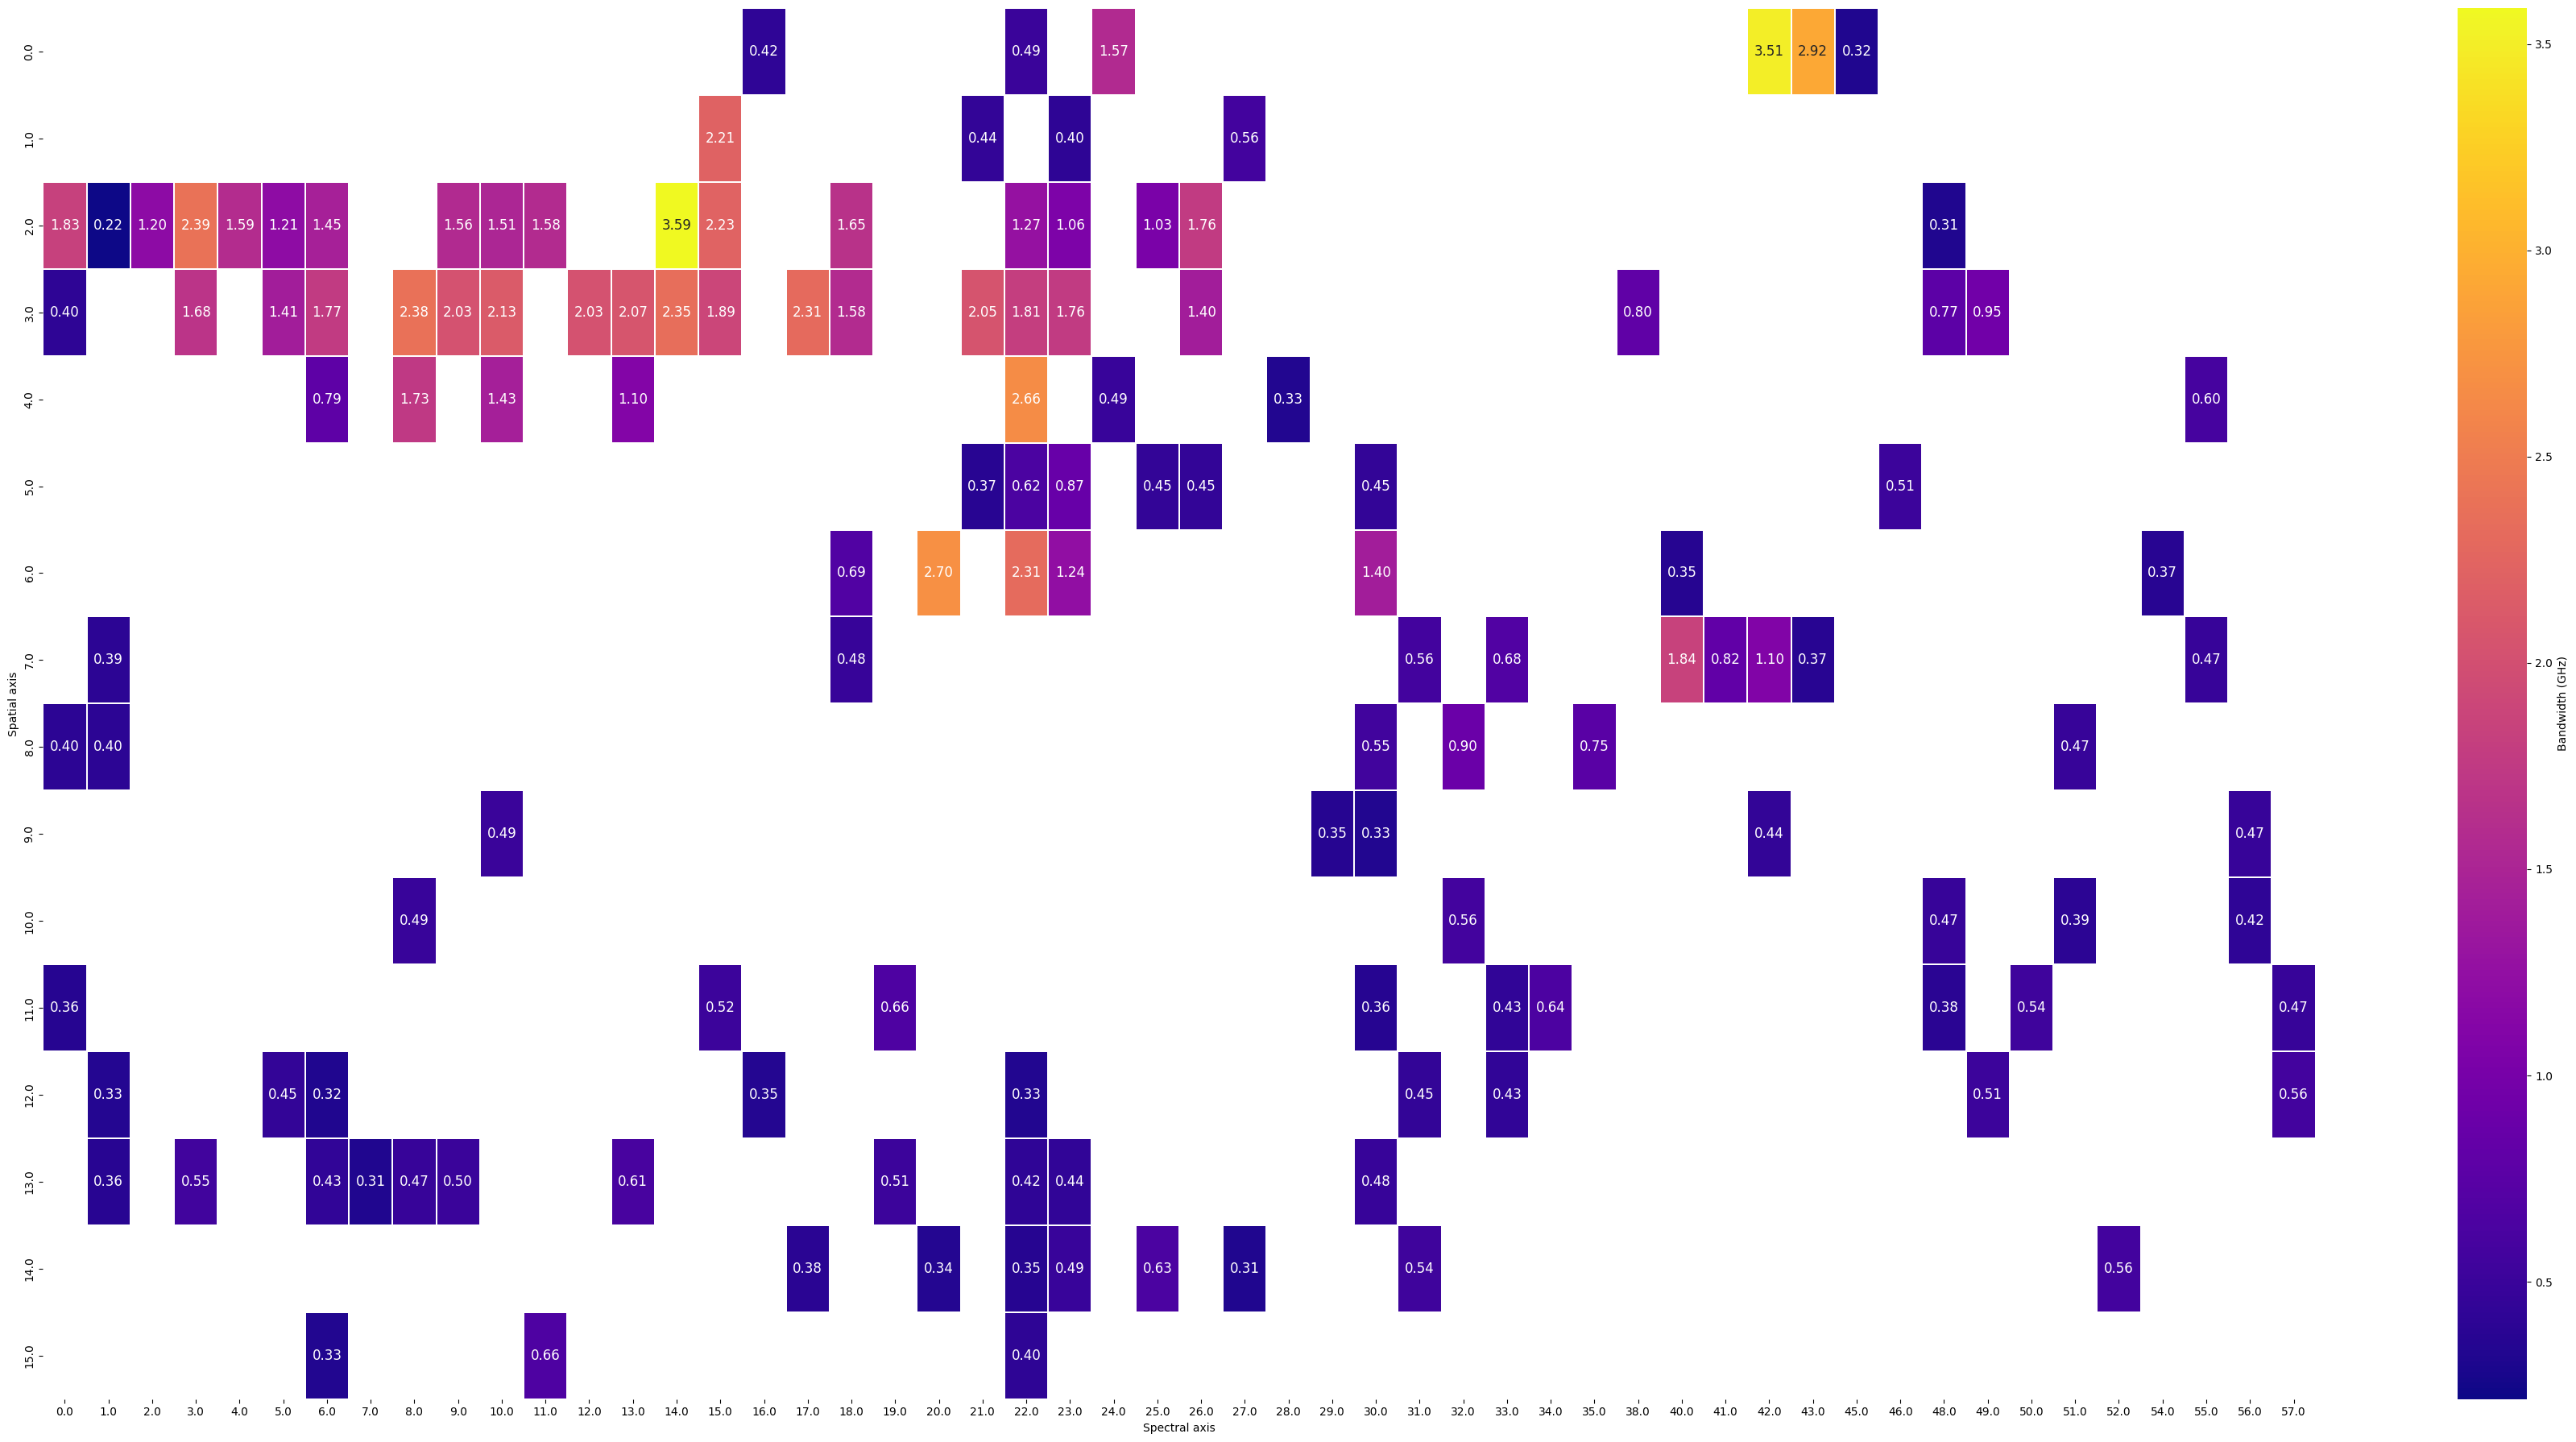

In [13]:
pivot_center = mce1_df.pivot_table(index='xf0', columns='xf1', values='center', aggfunc='median')

plt.figure(figsize=(36,18))
sns.heatmap(pivot_center, annot=True, fmt=".1f", cmap='plasma', cbar_kws={'label': 'Bandcenter (GHz)'}, linewidths=0.1, linecolor='white', annot_kws={"size": 10})
plt.xlabel('Spectral axis')
plt.ylabel('Spatial axis')
plt.tight_layout()
plt.show()

pivot_fwhm = mce1_df.pivot_table(index='xf0', columns='xf1', values='fwhm', aggfunc='median')

plt.figure(figsize=(36,18))
sns.heatmap(pivot_fwhm, annot=True, fmt=".2f", cmap='plasma', cbar_kws={'label': 'Bandwidth (GHz)'}, linewidths=0.1, linecolor='white' , annot_kws={"size": 12},)
plt.xlabel('Spectral axis')
plt.ylabel('Spatial axis')
plt.tight_layout()
plt.show()